In [1]:
import pandas as pd

In [2]:
from pathlib import Path
DATA_PATH = Path("/Users/vadik/brEcommerce")
tables = {
    'customers': 'olist_customers_dataset.csv', # клиенты
    'orders': 'olist_orders_dataset.csv', # заказы
    'items': 'olist_order_items_dataset.csv', # товары в заказах
    'payments': 'olist_order_payments_dataset.csv', # оплаты по заказам
    'reviews': 'olist_order_reviews_dataset.csv', # отзывы по заказам
    'products': 'olist_products_dataset.csv', # перечень товаров
    'sellers': 'olist_sellers_dataset.csv', # продавцы
    'geo': 'olist_geolocation_dataset.csv', # геолокации по зип-кодам
    'categories': 'product_category_name_translation.csv', # категории товаров
    'category_translations': 'product_category_name_translation.csv' # переводы названий категорий
}

data = {}
for name, filename in tables.items():
    filepath = DATA_PATH / filename
    if filepath.exists():
        data[name] = pd.read_csv(filepath)
        print(f"✅ {name}: {data[name].shape}")
    else:
        print(f"❌ Не найдено: {filename}")

✅ customers: (99441, 5)
✅ orders: (99441, 8)
✅ items: (112650, 7)
✅ payments: (103886, 5)
✅ reviews: (99224, 7)
✅ products: (32951, 9)
✅ sellers: (3095, 4)
✅ geo: (1000163, 5)
✅ categories: (71, 2)
✅ category_translations: (71, 2)


In [3]:
# Профилирование, поиск пропусков
def quick_profile(df, table_name):
    print(f"\n{'='*60}")
    print(f"📊 {table_name.upper()}")
    print(f"{'='*60}")
    print(f"Размер: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
    
    # Пропуски
    nulls = df.isnull().sum()
    if nulls.any():
        print(f"\n⚠️ Пропуски:")
        for col in nulls[nulls > 0].index:
            pct = nulls[col] / len(df) * 100
            print(f"  • {col}: {nulls[col]:,} ({pct:.1f}%)")
    
    # Пример строки с пропуском
    if nulls.any():
        col_with_null = nulls[nulls > 0].index[0]
        sample = df[df[col_with_null].isnull()].head(1)
        print(f"\nПример строки с пропуском в '{col_with_null}':")
        print(sample.iloc[0].to_dict())

# Проверяем для всех таблиц
for name, df in data.items():
    quick_profile(df, name)


📊 CUSTOMERS
Размер: 99,441 строк × 5 столбцов

📊 ORDERS
Размер: 99,441 строк × 8 столбцов

⚠️ Пропуски:
  • order_approved_at: 160 (0.2%)
  • order_delivered_carrier_date: 1,783 (1.8%)
  • order_delivered_customer_date: 2,965 (3.0%)

Пример строки с пропуском в 'order_approved_at':
{'order_id': '00b1cb0320190ca0daa2c88b35206009', 'customer_id': '3532ba38a3fd242259a514ac2b6ae6b6', 'order_status': 'canceled', 'order_purchase_timestamp': '2018-08-28 15:26:39', 'order_approved_at': nan, 'order_delivered_carrier_date': nan, 'order_delivered_customer_date': nan, 'order_estimated_delivery_date': '2018-09-12 00:00:00'}

📊 ITEMS
Размер: 112,650 строк × 7 столбцов

📊 PAYMENTS
Размер: 103,886 строк × 5 столбцов

📊 REVIEWS
Размер: 99,224 строк × 7 столбцов

⚠️ Пропуски:
  • review_comment_title: 87,656 (88.3%)
  • review_comment_message: 58,247 (58.7%)

Пример строки с пропуском в 'review_comment_title':
{'review_id': '7bc2406110b926393aa56f80a40eba40', 'order_id': '73fc7af87114b39712e6da79b0a377

In [4]:
# проверим связь товаров в заказах с заказами
order_ids_items = set(data['items']['order_id'].unique())
order_ids_orders = set(data['orders']['order_id'].unique())

empty_orders = order_ids_orders - order_ids_items
print(f"""🔍 Пустых заказов: {len(empty_orders)}
При этом заказов со статусом unavailable: {len(data['orders'][data['orders']['order_status'] == 'unavailable'])}
Кол-во заказов в предметах: {len(order_ids_items)} \nКол-во заказов всего:{len(order_ids_orders)}""")


if empty_orders:
    print("Примеры, id заказов:", list(empty_orders)[:3])

🔍 Пустых заказов: 775
При этом заказов со статусом unavailable: 609
Кол-во заказов в предметах: 98666 
Кол-во заказов всего:99441
Примеры, id заказов: ['80fd1b0b81771253d43532f41d575d39', '2f346d92b11fcc7c342b3392b174cf3b', '151e44f3dd461fe0838b6f59f884749f']


In [5]:
# смотрим, что за заказы, у которых нет товаров, но статус не unavailable
suspicious_orders = data['orders'][
    data['orders']['order_id'].isin(empty_orders) &
    (data['orders']['order_status'] != 'unavailable')]

suspicious_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,2017-04-10 00:00:00
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,2018-09-13 00:00:00
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,2017-05-30 00:00:00
...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaN,NaN,NaN,2017-07-25 00:00:00
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaN,NaN,NaN,2017-10-16 00:00:00
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00


In [6]:
# смотрим статусы подозрительных заказов
suspicious_orders['order_status'].value_counts()

order_status
canceled    164
created       5
invoiced      2
shipped       1
Name: count, dtype: int64

In [7]:
# и все статусы заказов
data['orders']['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [8]:
# проверяем связь orders → customers
orders_cust_ids = set(data['orders']['customer_id'].dropna().unique())
customers_ids = set(data['customers']['customer_id'].unique())

orphan_orders = orders_cust_ids - customers_ids
print(f"🔍 Заказы без клиента: {len(orphan_orders)}")

# Если есть сироты — покажи примеры
if orphan_orders:
    print("Примеры:", list(orphan_orders)[:3])

🔍 Заказы без клиента: 0


In [9]:
# распределение заказов по месяцам
data['orders']['order_purchase_timestamp'] = pd.to_datetime(data['orders']['order_purchase_timestamp'])

# Период
print(f"Период: {data['orders']['order_purchase_timestamp'].min()} → {data['orders']['order_purchase_timestamp'].max()}")

# Заказы по месяцам
monthly = data['orders'].groupby(data['orders']['order_purchase_timestamp'].dt.to_period('M')).size()
print("\nЗаказы по месяцам:")
print(monthly) 

Период: 2016-09-04 21:15:19 → 2018-10-17 17:30:18

Заказы по месяцам:
order_purchase_timestamp
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64


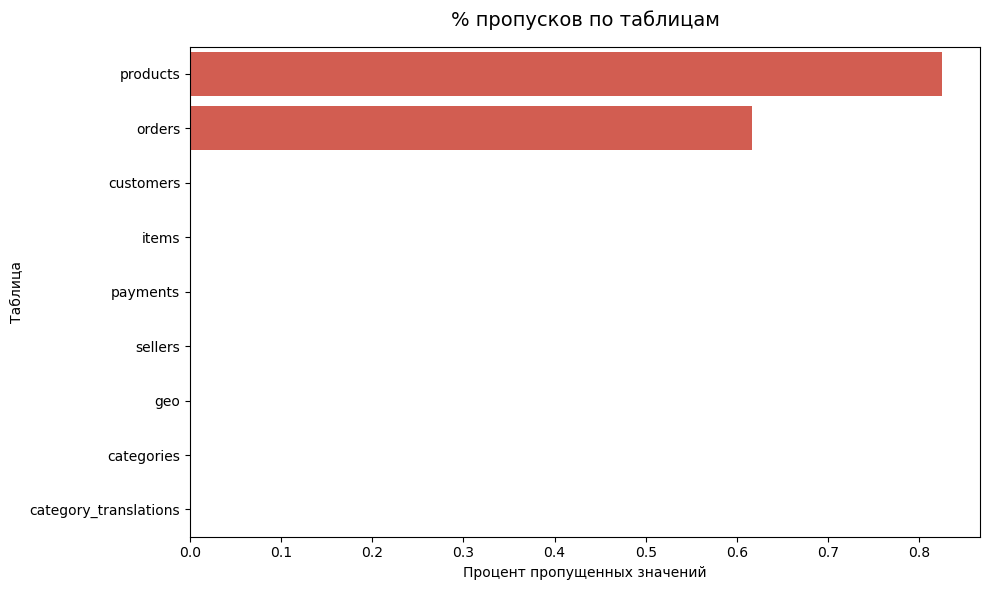

In [10]:
# График пропусков по таблицам
# за исключением reviews (много некритичных пропусков)

import matplotlib.pyplot as plt
import seaborn as sns

# Считаем % пропусков по таблицам
quality_summary = []
for name, df in data.items():
    if name == 'reviews':
        continue
    null_pct = df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100
    quality_summary.append({'table': name, 'null_pct': null_pct, 'rows': len(df)})

quality_df = pd.DataFrame(quality_summary).sort_values('null_pct', ascending=False)

# График
plt.figure(figsize=(10, 6))
sns.barplot(data=quality_df, x='null_pct', y='table', color='#e74c3c')
plt.title('% пропусков по таблицам', fontsize=14, pad=15)
plt.xlabel('Процент пропущенных значений')
plt.ylabel('Таблица')
plt.tight_layout()
plt.savefig('C:/Users/vadik/outputs/charts/data_quality_heatmap.png', dpi=150)
plt.show()

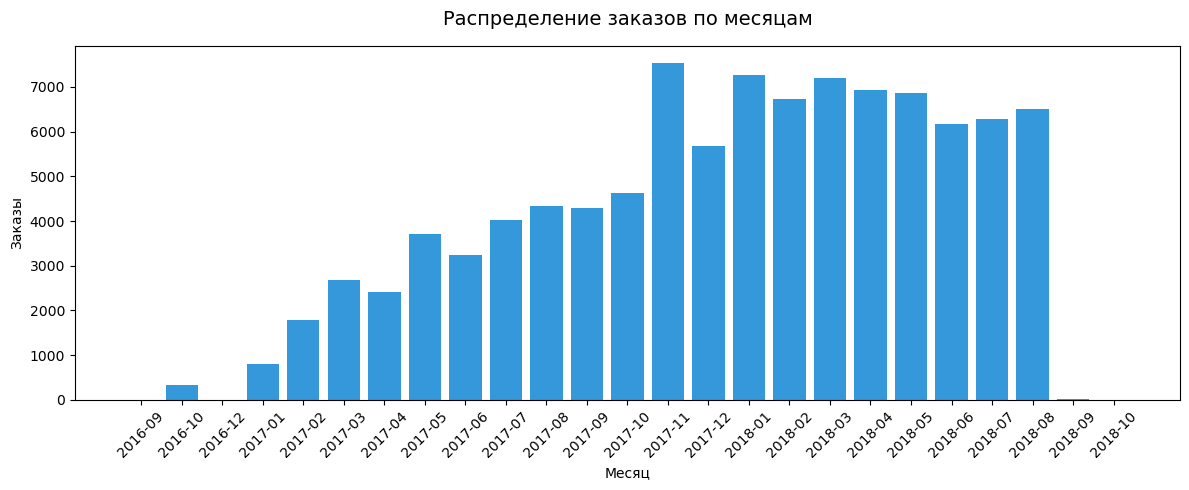

In [16]:
# Заказы по месяцам

# Агрегация по месяцам
monthly = data['orders'].groupby(data['orders']['order_purchase_timestamp'].dt.to_period('M')).size()
monthly_df = monthly.reset_index()
monthly_df.columns = ['month', 'orders']
monthly_df['month'] = monthly_df['month'].astype(str)

# График
plt.figure(figsize=(12, 5))
plt.bar(monthly_df['month'], monthly_df['orders'], color='#3498db')
plt.title('Распределение заказов по месяцам', fontsize=14, pad=15)
plt.xlabel('Месяц')
plt.ylabel('Заказы')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/charts/orders_over_time.png', dpi=150)
plt.show()

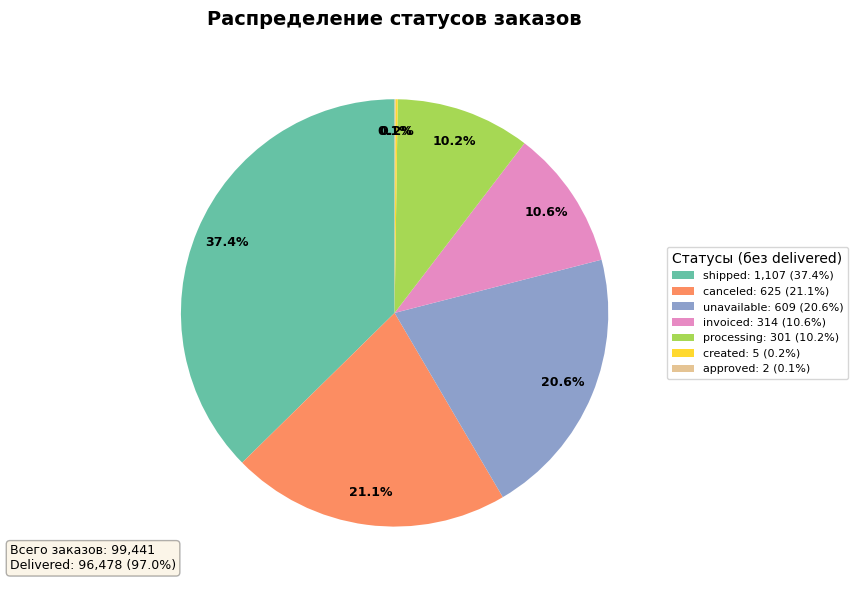

In [15]:
# Распределение статусов заказов
# Подготовка данных
status_counts = data['orders']['order_status'].value_counts()
status_counts_filtered = status_counts[status_counts.index != 'delivered']

# График
plt.figure(figsize=(10, 6))
wedges, texts, autotexts = plt.pie(
    status_counts_filtered.values,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 9, 'weight': 'bold'},
    pctdistance=0.85,
    colors=sns.color_palette('Set2', len(status_counts_filtered))
)

legend_labels = [
    f'{label}: {status_counts_filtered[label]:,} ({status_counts_filtered[label]/status_counts_filtered.sum()*100:.1f}%)'
    for label in status_counts_filtered.index
]
plt.legend(
    wedges,
    legend_labels,  # ← используем новые подписи
    title='Статусы (без delivered)',  # ← уточнили заголовок
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=8  # ← уменьшили, т.к. текст длиннее
)

# Статистика текстом
plt.text(
    -1.8, -1.2, 
    f'Всего заказов: {len(data["orders"]):,}\nDelivered: {status_counts.get("delivered", 0):,} ({status_counts.get("delivered", 0)/len(data["orders"])*100:.1f}%)',
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3)
)

plt.title('Распределение статусов заказов', fontsize=14, pad=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/charts/order_status_dist_final.png', dpi=150, bbox_inches='tight')
plt.show()